# 9 - The Infinte Square Well
## 9.1 - The Particle in a Box

The potential energy of the infinite square well:

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np

rc('text.latex',preamble='\\usepackage{libertine}\n\\usepackage[libertine]{newtxmath}')
rc('font',**{'family':'serif','serif':['Linux Libertine O']}, size=18)
rc('text', usetex=True)

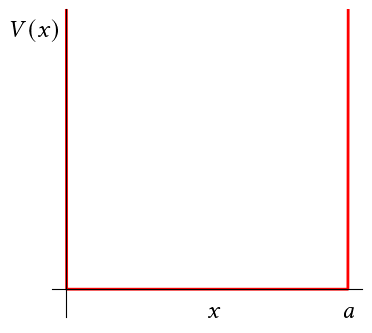

In [2]:
x = np.linspace(0, 1, 1000)
V = np.zeros(1000)
V[0] = 10
V[-1] = 10

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(x, V, color='red', lw=2)
ax.text(0.5, -1, r'$x$')
ax.text(0.98, -1, r'$a$')
ax.text(-0.2, 9, r'$V(x)$')

ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

#ax.text(-0.4, -0.0015, "A")
#ax.text(1.5, -0.0015, "B")
#ax.text(3.2, -0.0015, "C")

#ax.set_xlim(-2, 5)
ax.set_ylim(-1, 10)

plt.savefig('fig_isw_potential.pdf', bbox_inches='tight')

Classical probability:

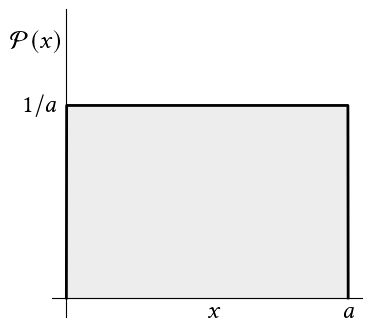

In [3]:
x = np.linspace(0, 1, 1000)
P = np.ones(1000)
P[0] = 0
P[-1] = 0

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(x, P, color='black', lw=2)
ax.text(0.5, -0.1, r'$x$')
ax.text(0.98, -0.1, r'$a$')
ax.text(-0.2, 1.3, r'$\mathcal{P}(x)$')
ax.text(-0.15, 0.97, r'$1/a$')
plt.fill_between(x, P, color="lightgray", alpha=0.4)

ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

#ax.text(-0.4, -0.0015, "A")
#ax.text(1.5, -0.0015, "B")
#ax.text(3.2, -0.0015, "C")

#ax.set_xlim(-2, 5)
ax.set_ylim(-0.1, 1.5)

plt.savefig('fig_isw_classical_prob.pdf', bbox_inches='tight')

## 9.2 The Allowed Energies and Wave Functions

The first three wave functions:

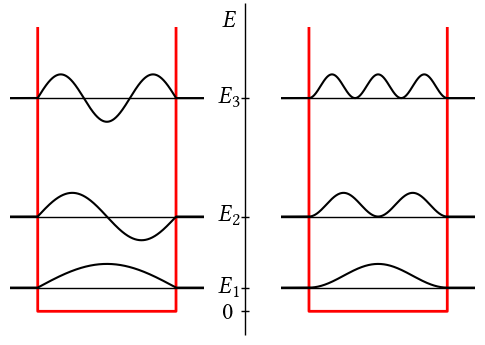

In [35]:
def V(x):
    a = 1
    return np.piecewise(x, (x<0, x > 0, x>a), (100, 0, 100))

def Phi(x, n = 1):
    a = 1
    return np.piecewise(x, (x<0, x > 0, x > a), (0, lambda x: np.sin(n * np.pi * x), 0))

def E(n = 1):
    return n**2

N = 1000

x = np.linspace(-0.2, 1.2, N)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 2, 1)
ax.axis('off')
ax.plot(x, V(x), color='red', lw=2)
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-1, 12)

# plot the wave functions
for n in range(1, 4):
    p = Phi(x, n)
    ax.plot(x, p + E(n), color='black')
    ax.axhline(E(n), color="black", lw=1)

ax.vlines(1.5, -1, 13, lw=1, clip_on=False, color='black')
ax.hlines([0, E(1), E(2), E(3)], 1.47, 1.53, lw=1, clip_on=False, color='black')
ax.text(1.33, 12, r'$E$', color='black')
ax.text(1.33, -0.3, '0')
ax.text(1.3, E(1)-0.2, r'$E_1$')
ax.text(1.3, E(2)-0.2, r'$E_2$')
ax.text(1.3, E(3)-0.2, r'$E_3$')
plt.subplots_adjust(wspace=0.4)

# and the squares
ax = fig.add_subplot(1, 2, 2)
ax.axis('off')
ax.plot(x, V(x), color='red', lw=2)
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-1, 12)
for n in range(1, 4):
    p = Phi(x, n)
    p2 = np.abs(p)**2
    ax.plot(x, p2 + E(n), color='black')
    ax.axhline(E(n), color="black", lw=1)

plt.savefig("fig_isw_wavefunctions.pdf", bbox_inches='tight')

Wave function with large $n$:

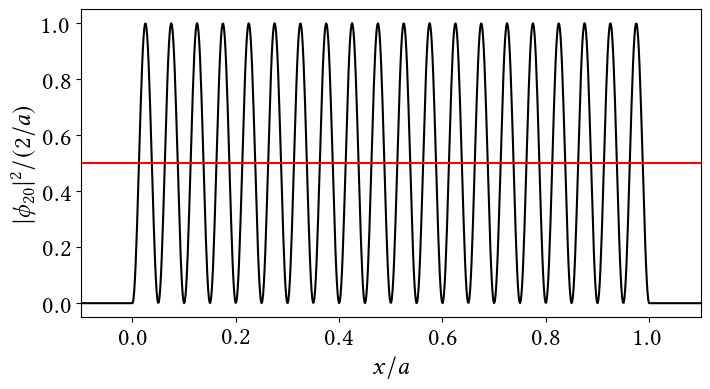

In [36]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(x, Phi(x, 20)**2, color='black')

ax.set_xlim(-0.1, 1.1)
ax.set_xlabel(r'$x/a$')
ax.set_ylabel(r'$|\phi_{20}|^2 / (2/a)$')

ax.axhline(0.5, color='red')

plt.savefig("fig_isw_large_n.pdf", bbox_inches='tight')

## 9.3 An Example

The initial wave function:

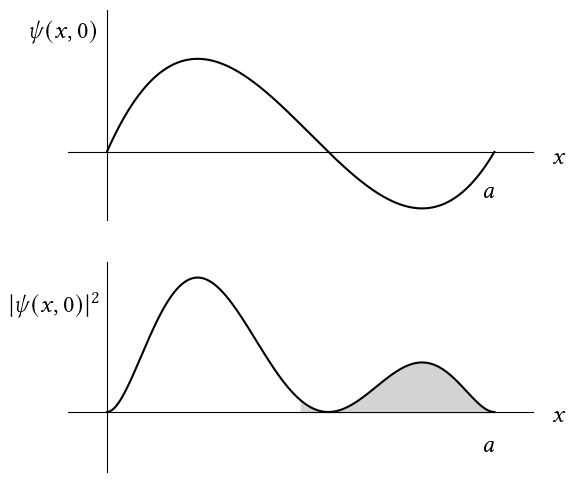

In [104]:
def psi_0(x):
    return np.piecewise(x, (x<0, x > 0, x > 1), (0, lambda x: np.sqrt(735) * ( x**3 - 11/7 * x**2 + 4/7*x), 0))

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(2, 1, 1)

ax.plot(x, psi_0(x), '-', color='black')

ax.text(1.15, -0.2, r'$x$')
ax.text(0.97, -0.8, r'$a$')
ax.text(-0.2, 2, r'$\psi(x, 0)$')

ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-1.2, 2.5)

ax = fig.add_subplot(2, 1, 2)

ax.plot(x, psi_0(x)**2, '-', color='black')

ax.text(1.15, -0.2, r'$x$')
ax.text(0.97, -0.8, r'$a$')
ax.text(-0.25, 2, r'$|\psi(x, 0)|^2$')

ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-1.2, 3)

ax.fill_between(x[x>0.5], psi_0(x[x>0.5])**2, color='lightgray')

plt.savefig("fig_isw_ex1.pdf", bbox_inches='tight')

Now for the wave function at a later time.  This is more complex.

c1 = 0.353
c2 = 0.927
c3 = 0.013
c4 = 0.116


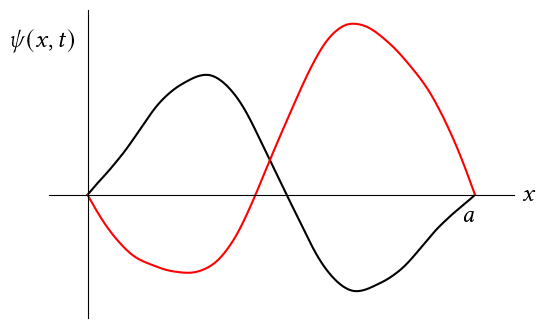

In [101]:
import scipy.integrate as integrate

def phi(x, n):
    return np.sqrt(2) * np.sin(n * np.pi * x)

def coef(n):
    c = integrate.quad(lambda x: phi(x, n) * psi_0(x), 0, 1)[0]
    return c

print(f"c1 = {coef(1):.3f}\nc2 = {coef(2):.3f}\nc3 = {coef(3):.3f}\nc4 = {coef(4):.3f}")

def psi_t(x, t):
    psi_e = 0 + 0j
    for i in range(50):
        n = i+1
        psi_e += coef(n) * phi(x, n) * np.exp(-1j * n**2 * np.pi**2 / 2.0 * t)

    return psi_e

x = np.linspace(0, 1, 1000)
z = psi_t(x, 1)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(x, np.real(z), color='black')
ax.plot(x, np.imag(z), color='red')

ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

ax.text(1.12, -0.05, r'$x$')
ax.text0.97, -0.22, r'$a$')
ax.text(-0.2, 1.2, r'$\psi(x, t)$')

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-1, 1.5)

plt.savefig("fig_isw_ex2.pdf", bbox_inches='tight')

Lastly, $|\psi|^2$ at a bunch of different times:

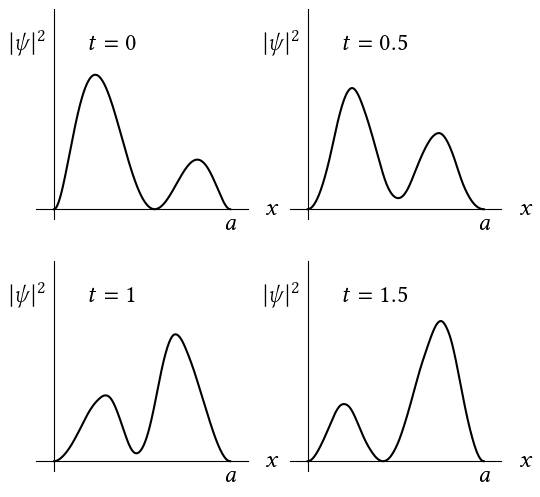

In [103]:
def plot1(ax, t):
    psi2 = np.abs(psi_t(x, t))**2
    ax.plot(x, psi2, color='black')
    ax.spines[['left', 'bottom']].set_position('zero')
    ax.spines[['top', 'right']].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(1.2, -0.1, r'$x$')
    ax.text(0.97, -0.4, r'$a$')
    ax.text(-0.25, 3.2, r'$|\psi|^2$')
    ax.text(0.2, 3.2, f'$t = {t}$')
    
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.2, 4)
    

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(2, 2, 1)
plot1(ax, 0)

ax = fig.add_subplot(2, 2, 2)
plot1(ax, 0.5)

ax = fig.add_subplot(2, 2, 3)
plot1(ax, 1)

ax = fig.add_subplot(2, 2, 4)
plot1(ax, 1.5)

plt.savefig("fig_isw_ex3.pdf", bbox_inches='tight')